# * Phase 3 Step 2 — SBERT Semantic Gate
## 5720570 — MSc Computer Science Dissertation
## University of Warwick | Supervisor: Dr. Ayse Saliha Sunar

### What is this notebook doing?

After applying 6 perturbation types (P1-P6) to 15,594 essays in Step 1, we now need to verify that each perturbation preserved the original meaning of the essay.

**Why do we need this check?**
- Our experiment only works if we changed the STYLE of the essay, not the MEANING
- If a perturbation accidentally changed the meaning, any score difference could be due to the meaning change, not the style change
- That would make our results invalid

**How does the check work?**
- We use a tool called Sentence-BERT (SBERT) which converts text into a numerical representation (a vector)
- We convert both the original essay and the perturbed essay into vectors
- We measure how similar the two vectors are using cosine similarity
- Cosine similarity of 1.0 = identical meaning, 0.0 = completely different meaning
- We set a threshold of 0.90 — any perturbation below this is thrown away

**Reference:** Reimers & Gurevych (2019) — Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks (EMNLP 2019)

In [1]:
# INSTALL AND IMPORT LIBRARIES

!pip install sentence-transformers --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine as cosine_distance
import time
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# LOAD SBERT MODEL

# What is SBERT?
# Regular BERT reads text and understands it, but its output vectors
# are not good for comparing two texts directly.
# SBERT is a special version of BERT trained specifically for 
# comparing texts using cosine similarity.
#
# We use 'all-MiniLM-L6-v2' which is:
# - Fast (6 layers instead of 12)
# - Good quality for similarity tasks
# - Produces 384-dimensional vectors
# - Published by Reimers & Gurevych (2019)

print("Loading SBERT model: all-MiniLM-L6-v2")
print("This will download the model from HuggingFace (first time only)...")

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"\nModel loaded successfully!")
print(f"Embedding dimensions: {sbert_model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {sbert_model.max_seq_length}")

Loading SBERT model: all-MiniLM-L6-v2
This will download the model from HuggingFace (first time only)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Model loaded successfully!
Embedding dimensions: 384
Max sequence length: 256


In [3]:
# LOAD THE PERTURBATION DATA FROM PHASE 3 STEP 1

df = pd.read_csv('/kaggle/input/datasets/shravaniuk/5720570-perturbations-full/perturbations_full_all6.csv')

print(f"Dataset loaded: {len(df):,} essays")
print(f"Columns: {df.columns.tolist()}")
print(f"\nScore distribution:")
print(df['score'].value_counts().sort_index())

print(f"\nPerturbation coverage (from Step 1):")
print(f"  P1 Lexical Formality  : {(df['p1_subs'] > 0).sum():,}/{len(df):,} ({(df['p1_subs'] > 0).mean()*100:.1f}%)")
print(f"  P2 Connective Density : {(df['p2_insertions'] > 0).sum():,}/{len(df):,} ({(df['p2_insertions'] > 0).mean()*100:.1f}%)")
print(f"  P3 Syntactic Voice    : {(df['p3_conversions'] > 0).sum():,}/{len(df):,} ({(df['p3_conversions'] > 0).mean()*100:.1f}%)")
print(f"  P4 Discourse Weakening: {df['p4_applied'].sum():,}/{len(df):,} ({df['p4_applied'].mean()*100:.1f}%)")
print(f"  P5 Structural Disrupt : {df['p5_applied'].sum():,}/{len(df):,} ({df['p5_applied'].mean()*100:.1f}%)")
print(f"  P6 Length Extension   : {(df['p6_fillers'] > 0).sum():,}/{len(df):,} ({(df['p6_fillers'] > 0).mean()*100:.1f}%)")

Dataset loaded: 15,594 essays
Columns: ['essay_id', 'score', 'original', 'p1_formality', 'p1_subs', 'p2_density', 'p2_insertions', 'p3_voice', 'p3_conversions', 'p6_length', 'p6_fillers', 'p4_weakening', 'p4_applied', 'p5_disruption', 'p5_applied']

Score distribution:
score
1     610
2    3218
3    4943
4    4194
5    2082
6     547
Name: count, dtype: int64

Perturbation coverage (from Step 1):
  P1 Lexical Formality  : 15,368/15,594 (98.6%)
  P2 Connective Density : 15,570/15,594 (99.8%)
  P3 Syntactic Voice    : 13,443/15,594 (86.2%)
  P4 Discourse Weakening: 3,533/15,594 (22.7%)
  P5 Structural Disrupt : 3,947/15,594 (25.3%)
  P6 Length Extension   : 15,594/15,594 (100.0%)


## Quick Test — Verify SBERT Works Correctly

Before running on 15,594 essays, we test SBERT on 3 simple examples to make sure it gives sensible results:

1. **Style change only** (should be HIGH similarity ~0.95+): "But we must act" vs "However we must act"
2. **Same meaning, passive voice** (should be HIGH ~0.90+): "The government introduced policies" vs "Policies were introduced by the government"  
3. **Completely different meaning** (should be LOW ~0.30): "Climate change is real" vs "The sky is green and cats are fish"

In [4]:
# QUICK TEST — VERIFY SBERT GIVES SENSIBLE RESULTS

test_pairs = [
    ("But we must act on this issue now.",
     "However we must act on this issue now.",
     "P1-style: informal to formal word swap"),
    
    ("The government introduced new education policies.",
     "New education policies were introduced by the government.",
     "P3-style: active to passive voice"),
    
    ("Climate change is real. We must act now.",
     "The sky is green and cats are fish.",
     "Completely different meaning (should FAIL gate)"),
]

print("SBERT Quick Test Results:")
print("=" * 70)

for orig, pert, description in test_pairs:
    # Encode both texts
    embeddings = sbert_model.encode([orig, pert], convert_to_numpy=True)
    
    # Compute cosine similarity (1 - cosine distance)
    similarity = 1.0 - cosine_distance(embeddings[0], embeddings[1])
    
    # Check if it passes the gate
    gate_result = "PASS" if similarity >= 0.90 else "FAIL"
    
    print(f"\n  Test: {description}")
    print(f"  Original : {orig}")
    print(f"  Perturbed: {pert}")
    print(f"  Similarity: {similarity:.4f} → {gate_result}")
    print(f"  {'✓ Correct — style change preserved meaning' if gate_result == 'PASS' and 'different' not in description else ''}")
    print(f"  {'✓ Correct — meaning changed, correctly rejected' if gate_result == 'FAIL' else ''}")

print("\n" + "=" * 70)
print("If the first two show PASS and the third shows FAIL, SBERT is working correctly.")

SBERT Quick Test Results:

  Test: P1-style: informal to formal word swap
  Original : But we must act on this issue now.
  Perturbed: However we must act on this issue now.
  Similarity: 0.9742 → PASS
  ✓ Correct — style change preserved meaning
  

  Test: P3-style: active to passive voice
  Original : The government introduced new education policies.
  Perturbed: New education policies were introduced by the government.
  Similarity: 0.9781 → PASS
  ✓ Correct — style change preserved meaning
  

  Test: Completely different meaning (should FAIL gate)
  Original : Climate change is real. We must act now.
  Perturbed: The sky is green and cats are fish.
  Similarity: 0.1750 → FAIL
  
  ✓ Correct — meaning changed, correctly rejected

If the first two show PASS and the third shows FAIL, SBERT is working correctly.


## Running SBERT Gate on All 15,594 Essays × 6 Perturbation Types

This is the main computation cell. For each essay and each perturbation type:

1. Take the original essay text (first 512 words to stay within model limits)
2. Take the perturbed essay text (first 512 words)
3. Encode both using SBERT into 384-dimensional vectors
4. Compute cosine similarity between the two vectors
5. If similarity >= 0.90 → PASS (meaning preserved, keep this perturbation)
6. If similarity < 0.90 → FAIL (meaning changed too much, discard this perturbation)

**Expected runtime:** 20-35 minutes on GPU T4

**Expected results:**
- P1, P2, P6 should have very high pass rates (95%+) because they make small changes
- P3 should have high pass rates (90%+) because passive voice preserves meaning
- P4 might have lower pass rates (~70-85%) because replacing argument segments changes content
- P5 might have lower pass rates (~60-80%) because removing a section changes content

In [5]:
# RUN SBERT GATE ON ALL ESSAYS × ALL PERTURBATION TYPES


SBERT_THRESHOLD = 0.90
BATCH_SIZE = 64  # Process 64 essays at a time for speed

# Define which columns contain perturbed text
PERTURBATION_COLS = {
    'p1': {'text_col': 'p1_formality',  'label': 'P1 Lexical Formality',  'filter_col': 'p1_subs',       'filter_type': 'greater_zero'},
    'p2': {'text_col': 'p2_density',    'label': 'P2 Connective Density', 'filter_col': 'p2_insertions', 'filter_type': 'greater_zero'},
    'p3': {'text_col': 'p3_voice',      'label': 'P3 Syntactic Voice',    'filter_col': 'p3_conversions','filter_type': 'greater_zero'},
    'p4': {'text_col': 'p4_weakening',  'label': 'P4 Discourse Weakening','filter_col': 'p4_applied',    'filter_type': 'boolean'},
    'p5': {'text_col': 'p5_disruption', 'label': 'P5 Structural Disruption','filter_col': 'p5_applied',  'filter_type': 'boolean'},
    'p6': {'text_col': 'p6_length',     'label': 'P6 Length Extension',   'filter_col': 'p6_fillers',    'filter_type': 'greater_zero'},
}

# Store results
similarity_scores = {}
gate_results = {}

total_start = time.time()

for pert_key, pert_info in PERTURBATION_COLS.items():
    text_col = pert_info['text_col']
    label    = pert_info['label']
    filter_col = pert_info['filter_col']
    filter_type = pert_info['filter_type']
    
    print(f"\n{'='*60}")
    print(f"Processing {label}...")
    print(f"{'='*60}")
    col_start = time.time()
    
    # Initialize arrays with zeros
    sims = np.zeros(len(df))
    
    # Process each essay
    for batch_start in range(0, len(df), BATCH_SIZE):
        batch_end = min(batch_start + BATCH_SIZE, len(df))
        
        orig_texts = []
        pert_texts = []
        valid_indices = []
        
        for i in range(batch_start, batch_end):
            row = df.iloc[i]
            original = str(row['original'])
            perturbed = str(row[text_col])
            
            # Check if perturbation was actually applied
            if filter_type == 'boolean':
                was_applied = row[filter_col] == True
            else:
                was_applied = row[filter_col] > 0
            
            # Skip if perturbation was not applied or text is empty/NaN
            if not was_applied or pd.isna(row[text_col]) or perturbed == 'nan' or perturbed == original:
                sims[i] = 0.0
                continue
            
            # Truncate to first 512 words for speed and model limits
            orig_trunc = ' '.join(original.split()[:512])
            pert_trunc = ' '.join(perturbed.split()[:512])
            
            orig_texts.append(orig_trunc)
            pert_texts.append(pert_trunc)
            valid_indices.append(i)
        
        # Batch encode if we have valid texts
        if len(orig_texts) > 0:
            all_texts = orig_texts + pert_texts
            embeddings = sbert_model.encode(all_texts,
                                            show_progress_bar=False,
                                            convert_to_numpy=True,
                                            batch_size=BATCH_SIZE)
            
            orig_embs = embeddings[:len(orig_texts)]
            pert_embs = embeddings[len(orig_texts):]
            
            for j, idx in enumerate(valid_indices):
                sim = 1.0 - cosine_distance(orig_embs[j], pert_embs[j])
                sims[idx] = float(sim)
        
        # Progress update
        if (batch_start // BATCH_SIZE) % 20 == 0:
            pct = (batch_end / len(df)) * 100
            print(f"  {batch_end:,}/{len(df):,} ({pct:.1f}%)")
    
    # Store results
    similarity_scores[pert_key] = sims
    gate_results[pert_key] = sims >= SBERT_THRESHOLD
    
    # Statistics
    # Only count essays where perturbation was actually applied
    if filter_type == 'boolean':
        applied_mask = df[filter_col] == True
    else:
        applied_mask = df[filter_col] > 0
    
    applied_sims = sims[applied_mask]
    col_time = (time.time() - col_start) / 60
    
    if len(applied_sims) > 0:
        pass_count = (applied_sims >= SBERT_THRESHOLD).sum()
        pass_pct = (pass_count / len(applied_sims)) * 100
        mean_sim = applied_sims[applied_sims > 0].mean() if (applied_sims > 0).any() else 0
        
        print(f"\n  Completed in {col_time:.1f} mins")
        print(f"  Essays with perturbation applied: {len(applied_sims):,}")
        print(f"  Mean similarity: {mean_sim:.4f}")
        print(f"  Gate PASSED: {pass_count:,}/{len(applied_sims):,} ({pass_pct:.1f}%)")
        print(f"  Gate FAILED: {len(applied_sims) - pass_count:,}/{len(applied_sims):,} ({100-pass_pct:.1f}%)")

total_time = (time.time() - total_start) / 60
print(f"\n{'='*60}")
print(f"ALL PERTURBATIONS PROCESSED IN {total_time:.1f} MINUTES")
print(f"{'='*60}")


Processing P1 Lexical Formality...
  64/15,594 (0.4%)
  1,344/15,594 (8.6%)
  2,624/15,594 (16.8%)
  3,904/15,594 (25.0%)
  5,184/15,594 (33.2%)
  6,464/15,594 (41.5%)
  7,744/15,594 (49.7%)
  9,024/15,594 (57.9%)
  10,304/15,594 (66.1%)
  11,584/15,594 (74.3%)
  12,864/15,594 (82.5%)
  14,144/15,594 (90.7%)
  15,424/15,594 (98.9%)

  Completed in 1.4 mins
  Essays with perturbation applied: 15,368
  Mean similarity: 0.9986
  Gate PASSED: 15,368/15,368 (100.0%)
  Gate FAILED: 0/15,368 (0.0%)

Processing P2 Connective Density...
  64/15,594 (0.4%)
  1,344/15,594 (8.6%)
  2,624/15,594 (16.8%)
  3,904/15,594 (25.0%)
  5,184/15,594 (33.2%)
  6,464/15,594 (41.5%)
  7,744/15,594 (49.7%)
  9,024/15,594 (57.9%)
  10,304/15,594 (66.1%)
  11,584/15,594 (74.3%)
  12,864/15,594 (82.5%)
  14,144/15,594 (90.7%)
  15,424/15,594 (98.9%)

  Completed in 1.6 mins
  Essays with perturbation applied: 15,570
  Mean similarity: 0.9682
  Gate PASSED: 15,456/15,570 (99.3%)
  Gate FAILED: 114/15,570 (0.7%)

P

In [6]:
# ADD SIMILARITY SCORES AND GATE FLAGS TO DATAFRAME

# Add similarity scores
for pert_key in PERTURBATION_COLS:
    df[f'sim_{pert_key}'] = similarity_scores[pert_key]
    df[f'gate_{pert_key}'] = gate_results[pert_key]

print("Added columns to dataframe:")
for pert_key, pert_info in PERTURBATION_COLS.items():
    print(f"  sim_{pert_key}  — cosine similarity score (0 to 1)")
    print(f"  gate_{pert_key} — True if passed gate (>= 0.90)")

print(f"\nTotal columns now: {len(df.columns)}")
print(f"Shape: {df.shape}")

Added columns to dataframe:
  sim_p1  — cosine similarity score (0 to 1)
  gate_p1 — True if passed gate (>= 0.90)
  sim_p2  — cosine similarity score (0 to 1)
  gate_p2 — True if passed gate (>= 0.90)
  sim_p3  — cosine similarity score (0 to 1)
  gate_p3 — True if passed gate (>= 0.90)
  sim_p4  — cosine similarity score (0 to 1)
  gate_p4 — True if passed gate (>= 0.90)
  sim_p5  — cosine similarity score (0 to 1)
  gate_p5 — True if passed gate (>= 0.90)
  sim_p6  — cosine similarity score (0 to 1)
  gate_p6 — True if passed gate (>= 0.90)

Total columns now: 27
Shape: (15594, 27)


In [7]:
# GATE SUMMARY TABLE

print("=" * 75)
print("SBERT SEMANTIC GATE — COMPLETE SUMMARY")
print("=" * 75)
print(f"{'Perturbation':<28} {'Applied':>8} {'Passed':>8} {'Failed':>8} {'Pass%':>8} {'MeanSim':>8}")
print("-" * 75)

summary_data = []

for pert_key, pert_info in PERTURBATION_COLS.items():
    label = pert_info['label']
    filter_col = pert_info['filter_col']
    filter_type = pert_info['filter_type']
    
    if filter_type == 'boolean':
        applied_mask = df[filter_col] == True
    else:
        applied_mask = df[filter_col] > 0
    
    applied_count = applied_mask.sum()
    sims = similarity_scores[pert_key][applied_mask]
    passed = (sims >= SBERT_THRESHOLD).sum()
    failed = applied_count - passed
    pass_pct = (passed / applied_count * 100) if applied_count > 0 else 0
    mean_sim = sims[sims > 0].mean() if (sims > 0).any() else 0
    
    print(f"  {label:<26} {applied_count:>8,} {passed:>8,} {failed:>8,} {pass_pct:>7.1f}% {mean_sim:>8.4f}")
    
    summary_data.append({
        'Perturbation': label,
        'Applied': applied_count,
        'Passed': passed,
        'Failed': failed,
        'Pass Rate': f'{pass_pct:.1f}%',
        'Mean Similarity': f'{mean_sim:.4f}'
    })

print("-" * 75)

# Save summary
df_summary = pd.DataFrame(summary_data)
df_summary.to_csv('/kaggle/working/sbert_gate_summary.csv', index=False)
print("\nSummary saved: sbert_gate_summary.csv")

SBERT SEMANTIC GATE — COMPLETE SUMMARY
Perturbation                  Applied   Passed   Failed    Pass%  MeanSim
---------------------------------------------------------------------------
  P1 Lexical Formality         15,368   15,368        0   100.0%   0.9986
  P2 Connective Density        15,570   15,456      114    99.3%   0.9682
  P3 Syntactic Voice           13,443   12,224    1,219    90.9%   0.9583
  P4 Discourse Weakening        3,533    1,595    1,938    45.1%   0.8233
  P5 Structural Disruption      3,947    3,926       21    99.5%   0.9877
  P6 Length Extension          15,594   15,456      138    99.1%   0.9947
---------------------------------------------------------------------------

Summary saved: sbert_gate_summary.csv


In [8]:
# CREATE VERIFIED DATASET — ONLY GATE-PASSING PERTURBATIONS
 
# For each perturbation type:
# - If gate PASSED: keep the perturbed text
# - If gate FAILED: set perturbed text to NaN (excluded from Phase 4)
#
# This ensures Phase 4 ablation study only uses perturbations
# where the meaning was preserved.

df_verified = df.copy()

for pert_key, pert_info in PERTURBATION_COLS.items():
    text_col = pert_info['text_col']
    gate_col = f'gate_{pert_key}'
    
    # Count before filtering
    before = df_verified[text_col].notna().sum()
    
    # Set failed perturbations to NaN
    df_verified.loc[~df_verified[gate_col], text_col] = np.nan
    
    # Count after filtering
    after = df_verified[text_col].notna().sum()
    
    print(f"  {pert_info['label']}: {before:,} → {after:,} (removed {before-after:,} failed)")

# Save verified dataset
df_verified.to_csv('/kaggle/working/perturbations_verified.csv', index=False)
print(f"\nVerified dataset saved: perturbations_verified.csv")
print(f"Shape: {df_verified.shape}")

print(f"\nFINAL VERIFIED COUNTS — Ready for Phase 4:")
print(f"  P1 Lexical Formality  : {df_verified['p1_formality'].notna().sum():,}")
print(f"  P2 Connective Density : {df_verified['p2_density'].notna().sum():,}")
print(f"  P3 Syntactic Voice    : {df_verified['p3_voice'].notna().sum():,}")
print(f"  P4 Discourse Weakening: {df_verified['p4_weakening'].notna().sum():,}")
print(f"  P5 Structural Disrupt : {df_verified['p5_disruption'].notna().sum():,}")
print(f"  P6 Length Extension   : {df_verified['p6_length'].notna().sum():,}")

  P1 Lexical Formality: 15,594 → 15,368 (removed 226 failed)
  P2 Connective Density: 15,594 → 15,456 (removed 138 failed)
  P3 Syntactic Voice: 15,594 → 12,224 (removed 3,370 failed)
  P4 Discourse Weakening: 6,980 → 1,595 (removed 5,385 failed)
  P5 Structural Disruption: 4,578 → 3,926 (removed 652 failed)
  P6 Length Extension: 15,594 → 15,456 (removed 138 failed)

Verified dataset saved: perturbations_verified.csv
Shape: (15594, 27)

FINAL VERIFIED COUNTS — Ready for Phase 4:
  P1 Lexical Formality  : 15,368
  P2 Connective Density : 15,456
  P3 Syntactic Voice    : 12,224
  P4 Discourse Weakening: 1,595
  P5 Structural Disrupt : 3,926
  P6 Length Extension   : 15,456


## Visualisation 1 — Similarity Distribution per Perturbation Type

This figure shows the distribution of cosine similarity scores for each perturbation type.

**How to read it:**
- X axis = cosine similarity (0 to 1)
- Y axis = number of essays
- Red dashed line = 0.90 threshold
- Essays to the RIGHT of the red line PASSED the gate (meaning was preserved)
- Essays to the LEFT FAILED (meaning changed too much, these are excluded)

**Expected pattern:**
- P1, P2 should cluster very close to 1.0 (small word changes barely affect meaning)
- P3 should cluster around 0.93-0.98 (passive voice changes meaning slightly)
- P4, P5 should be more spread out (content changes are larger)
- P6 should cluster high (adding words does not change existing meaning)

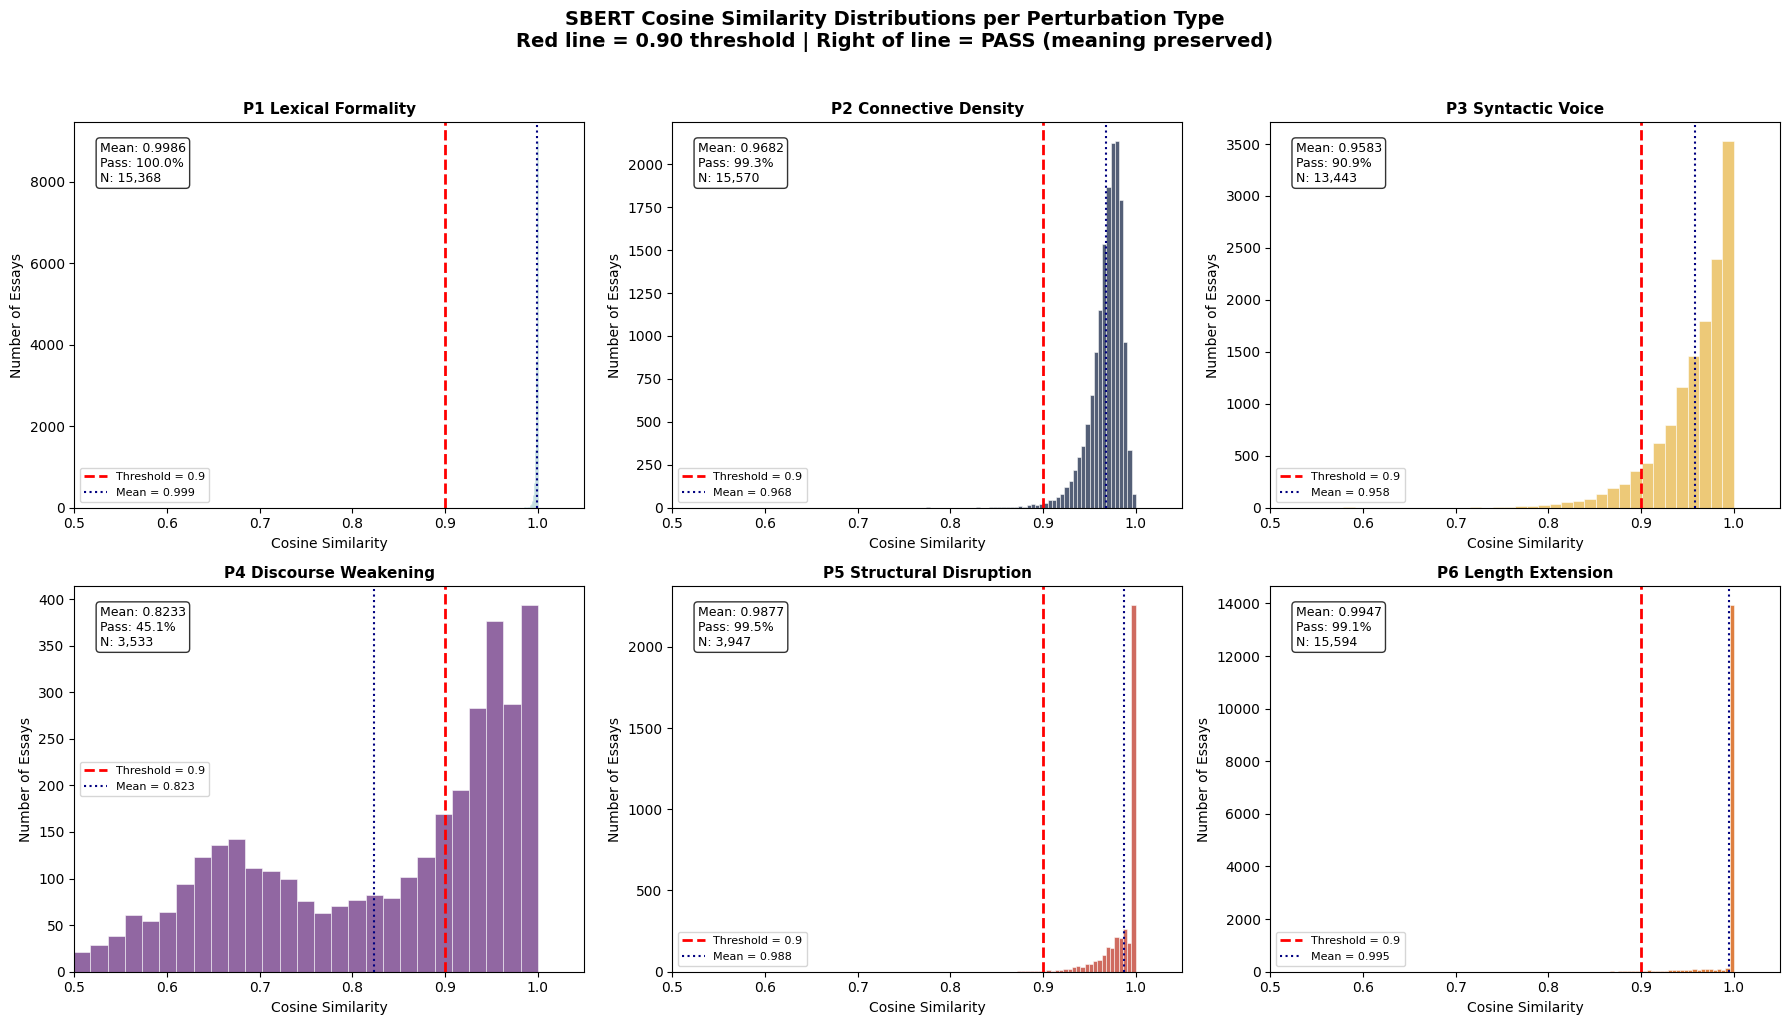

Saved: fig11_sbert_similarity_distributions.png


In [9]:
# VISUALISATION 1 — SIMILARITY DISTRIBUTIONS

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SBERT Cosine Similarity Distributions per Perturbation Type\n'
             'Red line = 0.90 threshold | Right of line = PASS (meaning preserved)',
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#0D7C8C', '#1B2A4A', '#E8B84B', '#6C3483', '#C0392B', '#D35400']
pert_keys = list(PERTURBATION_COLS.keys())

for idx, (ax, pert_key, color) in enumerate(zip(axes.flatten(), pert_keys, colors)):
    pert_info = PERTURBATION_COLS[pert_key]
    filter_col = pert_info['filter_col']
    filter_type = pert_info['filter_type']
    
    # Get similarity values only for essays where perturbation was applied
    if filter_type == 'boolean':
        applied_mask = df[filter_col] == True
    else:
        applied_mask = df[filter_col] > 0
    
    sim_vals = similarity_scores[pert_key][applied_mask]
    sim_vals = sim_vals[sim_vals > 0]  # Remove zeros (not applied)
    
    if len(sim_vals) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{pert_info["label"]}', fontweight='bold')
        continue
    
    # Histogram
    ax.hist(sim_vals, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    
    # Threshold line
    ax.axvline(x=SBERT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {SBERT_THRESHOLD}')
    
    # Mean line
    mean_sim = sim_vals.mean()
    ax.axvline(x=mean_sim, color='navy', linestyle=':', linewidth=1.5, label=f'Mean = {mean_sim:.3f}')
    
    # Stats box
    pass_rate = (sim_vals >= SBERT_THRESHOLD).mean() * 100
    ax.text(0.05, 0.95, f'Mean: {mean_sim:.4f}\nPass: {pass_rate:.1f}%\nN: {len(sim_vals):,}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{pert_info["label"]}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Cosine Similarity', fontsize=10)
    ax.set_ylabel('Number of Essays', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(0.5, 1.05)

plt.tight_layout()
plt.savefig('/kaggle/working/fig11_sbert_similarity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig11_sbert_similarity_distributions.png")

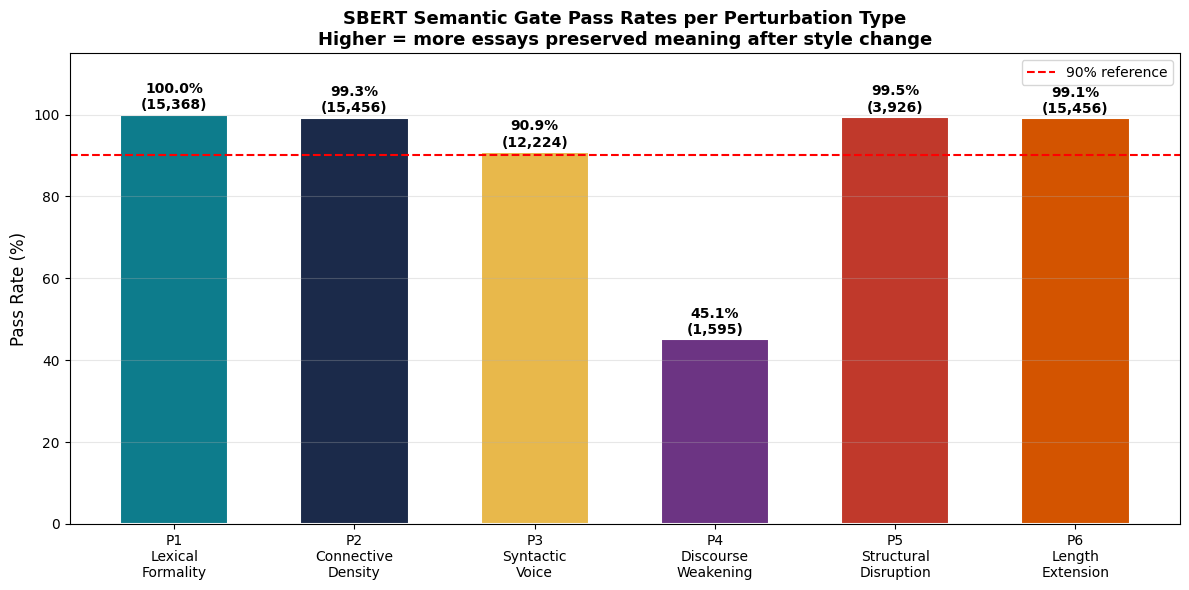

Saved: fig12_gate_pass_rates.png


In [10]:
# VISUALISATION 2 — GATE PASS RATES BAR CHART

fig, ax = plt.subplots(figsize=(12, 6))

pass_rates = []
total_valid = []
pert_names = []

for pert_key, pert_info in PERTURBATION_COLS.items():
    filter_col = pert_info['filter_col']
    filter_type = pert_info['filter_type']
    
    if filter_type == 'boolean':
        applied_mask = df[filter_col] == True
    else:
        applied_mask = df[filter_col] > 0
    
    applied_count = applied_mask.sum()
    sims = similarity_scores[pert_key][applied_mask]
    passed = (sims >= SBERT_THRESHOLD).sum()
    
    pass_rates.append((passed / applied_count * 100) if applied_count > 0 else 0)
    total_valid.append(passed)
    pert_names.append(pert_info['label'].replace(' ', '\n'))

bar_colors = ['#0D7C8C', '#1B2A4A', '#E8B84B', '#6C3483', '#C0392B', '#D35400']
bars = ax.bar(pert_names, pass_rates, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)

# Value labels on bars
for bar, rate, n in zip(bars, pass_rates, total_valid):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{rate:.1f}%\n({n:,})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% reference')
ax.set_ylim(0, 115)
ax.set_ylabel('Pass Rate (%)', fontsize=12)
ax.set_title('SBERT Semantic Gate Pass Rates per Perturbation Type\n'
             'Higher = more essays preserved meaning after style change',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/fig12_gate_pass_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig12_gate_pass_rates.png")

In [11]:
# EXAMPLES — WHAT PASSES AND WHAT FAILS

print("=" * 70)
print("SBERT GATE EXAMPLES")
print("=" * 70)

for pert_key in ['p1', 'p3', 'p4']:
    pert_info = PERTURBATION_COLS[pert_key]
    text_col = pert_info['text_col']
    sim_col = f'sim_{pert_key}'
    gate_col = f'gate_{pert_key}'
    
    print(f"\n{'='*70}")
    print(f"{pert_info['label']}")
    print(f"{'='*70}")
    
    # Show 1 PASS example
    passes = df[df[gate_col] == True].head(1)
    for _, row in passes.iterrows():
        print(f"\n  PASS (similarity={row[sim_col]:.4f})")
        print(f"  Original (first 150 chars): {str(row['original'])[:150]}...")
        print(f"  Perturbed (first 150 chars): {str(row[text_col])[:150]}...")
    
    # Show 1 FAIL example
    fails = df[(df[sim_col] > 0) & (df[gate_col] == False)].head(1)
    for _, row in fails.iterrows():
        print(f"\n  FAIL (similarity={row[sim_col]:.4f}) — EXCLUDED from Phase 4")
        print(f"  Original (first 150 chars): {str(row['original'])[:150]}...")
        print(f"  Perturbed (first 150 chars): {str(row[text_col])[:150]}...")

SBERT GATE EXAMPLES

P1 Lexical Formality

  PASS (similarity=0.9992)
  Original (first 150 chars): Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and fo...
  Perturbed (first 150 chars): Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and fo...

P3 Syntactic Voice

  PASS (similarity=0.9783)
  Original (first 150 chars): Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and fo...
  Perturbed (first 150 chars): Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and fo...

  FAIL (similarity=0.8487) — EXCLUDED from Phase 4
  Original (first 150 chars): Ever since phones have entered into the world, it has since th

## Phase 3 Step 2 — Complete

**What was done:**
- Loaded SBERT model (all-MiniLM-L6-v2, Reimers & Gurevych 2019)
- Computed cosine similarity between original and perturbed text for all 15,594 essays across all 6 perturbation types
- Applied gate threshold of 0.90 — perturbations below this are excluded
- Created verified dataset containing only gate-passing perturbations

**Output files:**
- `perturbations_verified.csv` — clean dataset ready for Phase 4 ablation study
- `sbert_gate_summary.csv` — gate statistics per perturbation type
- `fig11_sbert_similarity_distributions.png` — histogram of similarity scores
- `fig12_gate_pass_rates.png` — bar chart of pass rates

**Next step:** Phase 4 — Score all verified perturbed essays with BERT and Longformer, compute MAS values

In [12]:
# PHASE 3 STEP 2 — FINAL SUMMARY

print("=" * 70)
print("PHASE 3 STEP 2 — SBERT SEMANTIC GATE — COMPLETE")
print("=" * 70)
print()
print("VERIFIED DATASET READY FOR PHASE 4 ABLATION STUDY")
print()
print("Verified essays per perturbation:")
print("-" * 70)
print(f"  P1 Lexical Formality  : {df_verified['p1_formality'].notna().sum():,}")
print(f"  P2 Connective Density : {df_verified['p2_density'].notna().sum():,}")
print(f"  P3 Syntactic Voice    : {df_verified['p3_voice'].notna().sum():,}")
print(f"  P4 Discourse Weakening: {df_verified['p4_weakening'].notna().sum():,}")
print(f"  P5 Structural Disrupt : {df_verified['p5_disruption'].notna().sum():,}")
print(f"  P6 Length Extension   : {df_verified['p6_length'].notna().sum():,}")
print("-" * 70)
print()
print("Output files:")
print("  perturbations_verified.csv")
print("  sbert_gate_summary.csv")
print("  fig11_sbert_similarity_distributions.png")
print("  fig12_gate_pass_rates.png")
print()
print("Next: Phase 4 — Ablation Study")
print("  1. Load perturbations_verified.csv")
print("  2. Load best_bert_aes_model.pt from Phase 2")
print("  3. Score original and perturbed essays with BERT")
print("  4. Score original and perturbed essays with Longformer")
print("  5. Compute MAS per perturbation type per model")
print("  6. Run CIV regression with permutation test B=5000")

PHASE 3 STEP 2 — SBERT SEMANTIC GATE — COMPLETE

VERIFIED DATASET READY FOR PHASE 4 ABLATION STUDY

Verified essays per perturbation:
----------------------------------------------------------------------
  P1 Lexical Formality  : 15,368
  P2 Connective Density : 15,456
  P3 Syntactic Voice    : 12,224
  P4 Discourse Weakening: 1,595
  P5 Structural Disrupt : 3,926
  P6 Length Extension   : 15,456
----------------------------------------------------------------------

Output files:
  perturbations_verified.csv
  sbert_gate_summary.csv
  fig11_sbert_similarity_distributions.png
  fig12_gate_pass_rates.png

Next: Phase 4 — Ablation Study
  1. Load perturbations_verified.csv
  2. Load best_bert_aes_model.pt from Phase 2
  3. Score original and perturbed essays with BERT
  4. Score original and perturbed essays with Longformer
  5. Compute MAS per perturbation type per model
  6. Run CIV regression with permutation test B=5000
